# 11 · Evaluación final en test

Evalúa una sola vez sobre test el modelo elegido en validación: **YOLO26s
entrenado y evaluado a 768 px**, con umbrales **0,36 para humo y 0,16 para
fuego**.

Resultados: **precisión 67,88 %, recall 77,32 % y F1 72,29 %** (micro),
**mAP50 79,27 %** y **mAP50-95 46,38 %**. Hay alarma en 21 de las 2.005
imágenes sin humo ni fuego (1,05 %), una imagen por encima del límite del 1 %
fijado en validación. Los umbrales no se cambian después de ver este
resultado.

El notebook es de solo lectura: no permite volver a evaluar, buscar otros
umbrales ni comparar modelos con test.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Muestra la única evaluación del modelo final sobre test. |
| **Cuándo abrirlo** | Para consultar las cifras finales de la memoria (Sección 5). |
| **Comportamiento por defecto** | Solo lectura: no permite volver a evaluar, cambiar los umbrales ni elegir otro modelo. |
| **Entradas principales** | Modelo congelado y umbrales humo 0,36 / fuego 0,16. |
| **Salidas principales** | Tablas y figuras, copiadas en `results/final_test/`. |
| **Continuación** | `12_DFire_interpretabilidad_modelo.ipynb`. |

> **Para ejecutarlo:** usar el entorno Docker de notebooks (sección 4 del
> `README.md` principal). Volver a ejecutarlo requiere resultados intermedios
> (`artifacts/experiments/` y otras carpetas de `artifacts/`) que no están en el
> repositorio; ver `notebooks/README.md`.

## Condiciones de la evaluación

- Modelo: `yolo26s_dfire_seed42_20260912T165304Z`, congelado antes de abrir test.
- Umbrales: humo 0,36 y fuego 0,16. Una detección es correcta si solapa al
  menos un 50 % con la caja real.
- Límite fijado en validación: como mucho un 1 % de imágenes sin humo ni fuego
  con alarma.
- El mAP se calcula con las métricas estándar de Ultralytics; los aciertos y
  errores, con los umbrales anteriores.
- El conjunto de test se había usado antes una vez para evaluar un YOLOv8s
  inicial, pero nunca con el YOLO26s final.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

def find_root(start=Path.cwd()):
    for candidate in [start, *start.parents, Path('/workspace/TFM')]:
        if (candidate / 'artifacts/15_final_test_evaluation/test/evaluation_state.json').is_file():
            return candidate.resolve()
    raise FileNotFoundError('No se encuentra el artefacto final de test')

ROOT = find_root()
PARENT = ROOT / 'artifacts/15_final_test_evaluation/test'
state = json.loads((PARENT / 'evaluation_state.json').read_text(encoding='utf-8'))
assert state['status'] == 'complete'
assert state['single_final_evaluation'] is True
assert state['inference_attempts'] == 1
RUN = ROOT / state['run_rel']
summary = json.loads((RUN / 'run_summary.json').read_text(encoding='utf-8'))
verification = json.loads((RUN / 'verification_report.json').read_text(encoding='utf-8'))
assert verification['status'] == 'passed'
assert summary['threshold_search_executed'] is False
assert summary['model_comparison_executed'] is False
print(f"Artefacto cerrado: {RUN.relative_to(ROOT)}")
print(f"Checkpoint SHA-256: {summary['weights_sha256']}")
print(f"Verificación: {verification['status']} · intentos de inferencia: {state['inference_attempts']}")

Artefacto cerrado: artifacts/15_final_test_evaluation/test/20260914T225451Z_140421b4
Checkpoint SHA-256: bfb54c4726519fb473bb7c4825577e51c05af2b0db5fd46bf1931a8a29285f67
Verificación: passed · intentos de inferencia: 1


## Datos

Antes de mostrar resultados se comprueba que el número de imágenes y cajas de
test coincide con el dataset preparado.

In [2]:
population = summary['observed_test_population']
pd.DataFrame([
    {'Unidad': 'Imágenes', 'Test': population['images']},
    {'Unidad': 'Imágenes negativas', 'Test': population['negative_images']},
    {'Unidad': 'Cajas de humo', 'Test': population['smoke_boxes']},
    {'Unidad': 'Cajas de fuego', 'Test': population['fire_boxes']},
]).style.format({'Test': '{:,.0f}'})

,Unidad,Test
0,Imágenes,"4,306"
1,Imágenes negativas,"2,005"
2,Cajas de humo,"2,311"
3,Cajas de fuego,"2,878"


## Resultados

### 1. Métricas estándar

La fila global es la media de humo y fuego (macro). El F1 se calcula a partir
de la precisión y el recall estándar. El mAP50-95 promedia el mAP con IoU de
0,50 a 0,95.

In [3]:
standard = pd.read_csv(RUN / 'test_standard_metrics.csv')
standard_display = standard[['scope','precision','recall','f1','mAP50','mAP50_95']].copy()
standard_display['scope'] = standard_display.scope.map({'all_macro':'Global','smoke':'Humo','fire':'Fuego'})
display(standard_display.style.format({c:'{:.2%}' for c in ['precision','recall','f1','mAP50','mAP50_95']}))

,scope,precision,recall,f1,mAP50,mAP50_95
0,Global,78.67%,72.77%,75.61%,79.27%,46.38%
1,Humo,84.16%,80.48%,82.28%,85.67%,53.65%
2,Fuego,73.19%,65.06%,68.88%,72.86%,39.10%


### 2. Resultados con los umbrales finales

Estas son las cifras que corresponden a humo 0,36 y fuego 0,16.

In [4]:
operating = pd.read_csv(RUN / 'test_operating_metrics.csv').iloc[0]
classes = pd.read_csv(RUN / 'test_class_metrics.csv')
class_display = classes[classes.scope.isin(['smoke','fire'])][['scope','tp','fp','fn','precision','recall','f1']].copy()
class_display['scope'] = class_display.scope.map({'smoke':'Humo','fire':'Fuego'})
display(class_display.style.format({c:'{:.2%}' for c in ['precision','recall','f1']}))
pd.DataFrame([{
    'Precisión micro': operating.precision,
    'Recall micro': operating.recall,
    'F1 micro': operating.f1,
    'Recall macro': operating.macro_recall,
    'Recall de la clase peor': operating.minimum_class_recall,
}]).style.format('{:.2%}')

,scope,tp,fp,fn,precision,recall,f1
0,Humo,1836,339,475,84.41%,79.45%,81.85%
1,Fuego,2176,1559,702,58.26%,75.61%,65.81%


,Precisión micro,Recall micro,F1 micro,Recall macro,Recall de la clase peor
0,67.88%,77.32%,72.29%,77.53%,75.61%


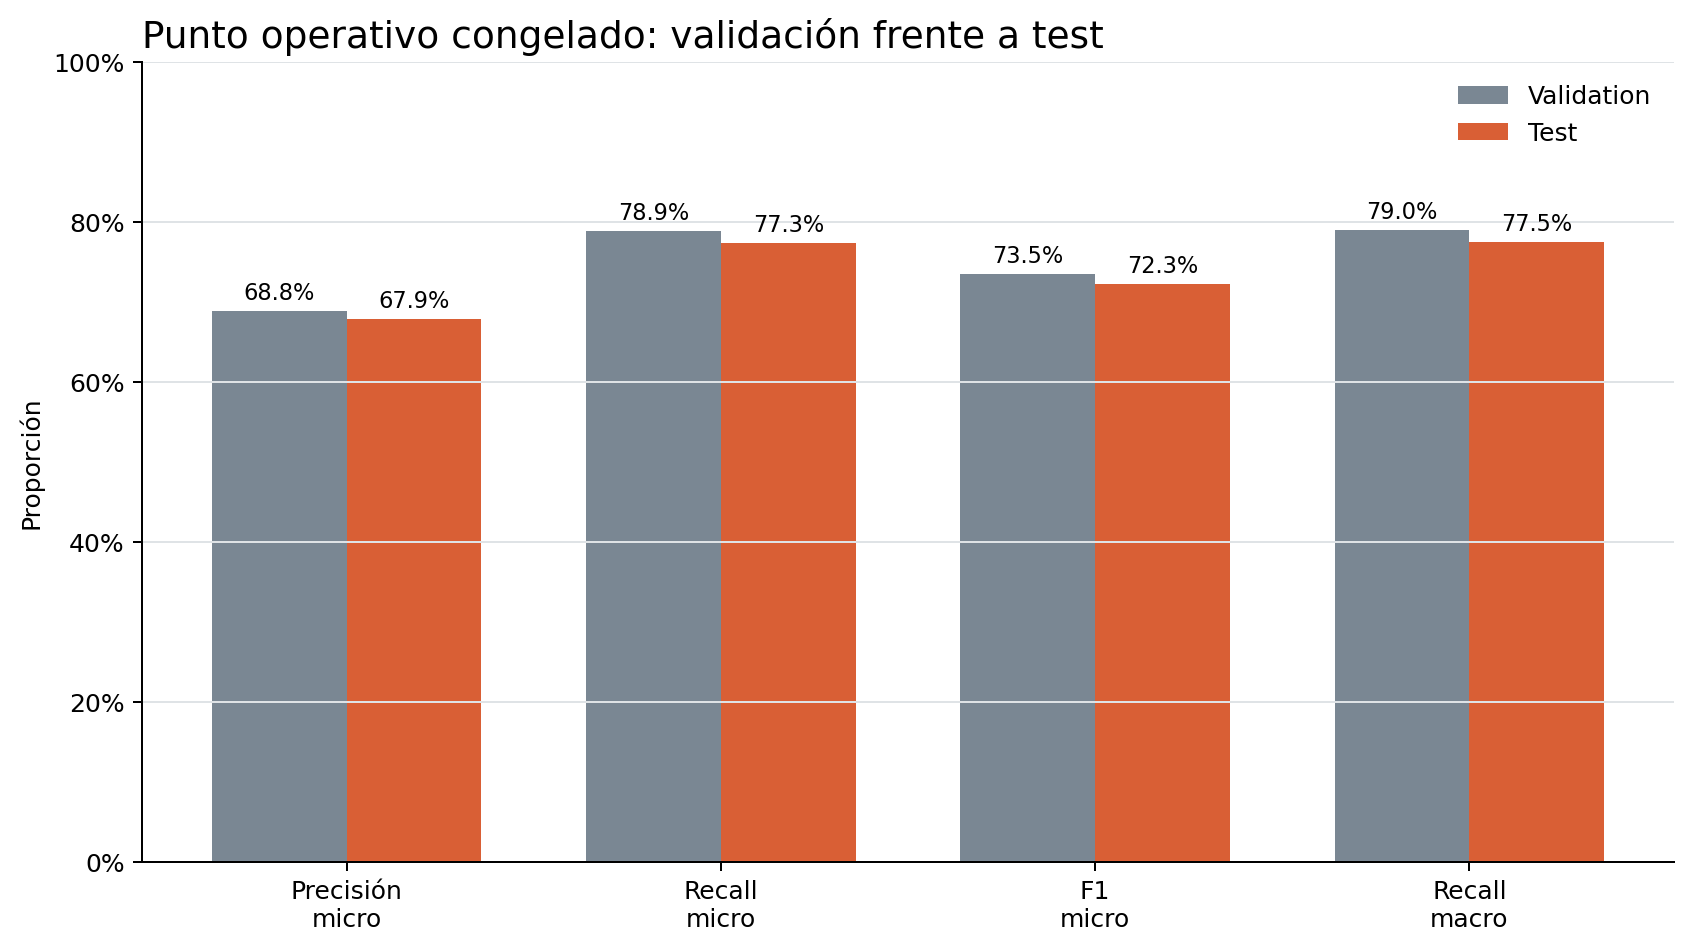

In [5]:
display(Image(filename=str(RUN / 'figures/01_operating_validation_vs_test.png'), width=900))

Respecto a validación, en test la precisión micro baja 0,94 puntos, el recall
micro 1,60, el F1 micro 1,23 y el recall macro 1,42. La mayor caída es la del
recall de fuego (−2,92 puntos).

### 3. Recall por clase y tamaño

,class_name,size_band,gt_boxes,tp,fn,recall
0,Fuego,Pequeño (<1 %),1860,1369,491,73.60%
1,Fuego,Mediano (1–10 %),848,672,176,79.25%
2,Fuego,Grande (≥10 %),170,135,35,79.41%
3,Humo,Pequeño (<1 %),495,327,168,66.06%
4,Humo,Mediano (1–10 %),541,375,166,69.32%
5,Humo,Grande (≥10 %),1275,1134,141,88.94%


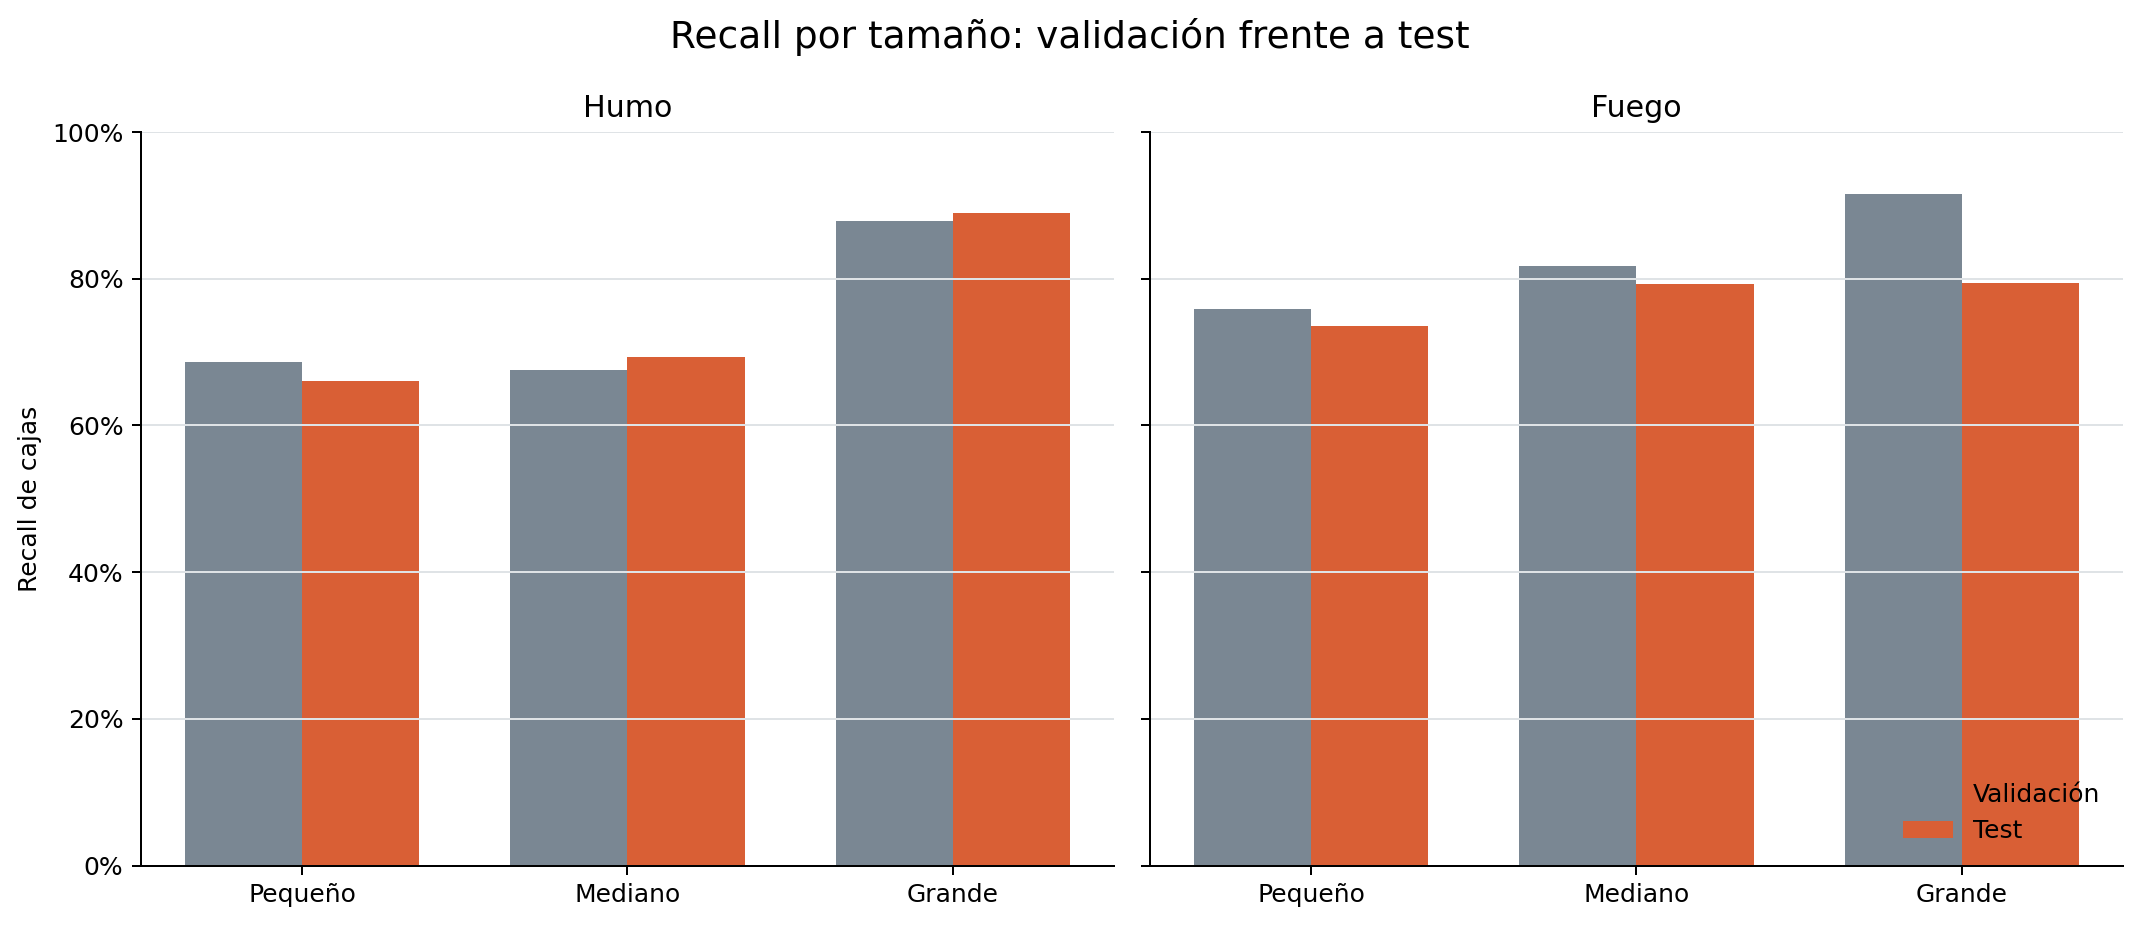

In [6]:
sizes = pd.read_csv(RUN / 'test_size_metrics.csv')
size_display = sizes[['class_name','size_band','gt_boxes','tp','fn','recall']].copy()
size_display['class_name'] = size_display.class_name.map({'smoke':'Humo','fire':'Fuego'})
size_display['size_band'] = size_display.size_band.map({'small':'Pequeño (<1 %)','medium':'Mediano (1–10 %)','large':'Grande (≥10 %)'})
display(size_display.style.format({'recall':'{:.2%}'}))
display(Image(filename=str(RUN / 'figures/03_size_validation_vs_test.png'), width=1000))

Lo más difícil siguen siendo los objetos pequeños: 66,06 % de recall en humo y
73,60 % en fuego. La caída en fuego grande (−12,14 puntos) hay que leerla con
cuidado, porque son pocas cajas (170 en test y 71 en validación).

### 4. Errores y alarmas en imágenes sin humo ni fuego

,Pred. humo,Pred. fuego,Pred. fondo
actual,,,
Humo real,1836,11,464
Fuego real,12,2176,690
Fondo real,327,1548,0


,scope,negative_images,negative_images_with_alarm,negative_image_false_alarm_rate
0,any,2005,21,1.047%
1,smoke,2005,14,0.698%
2,fire,2005,7,0.349%
3,both,2005,0,0.000%


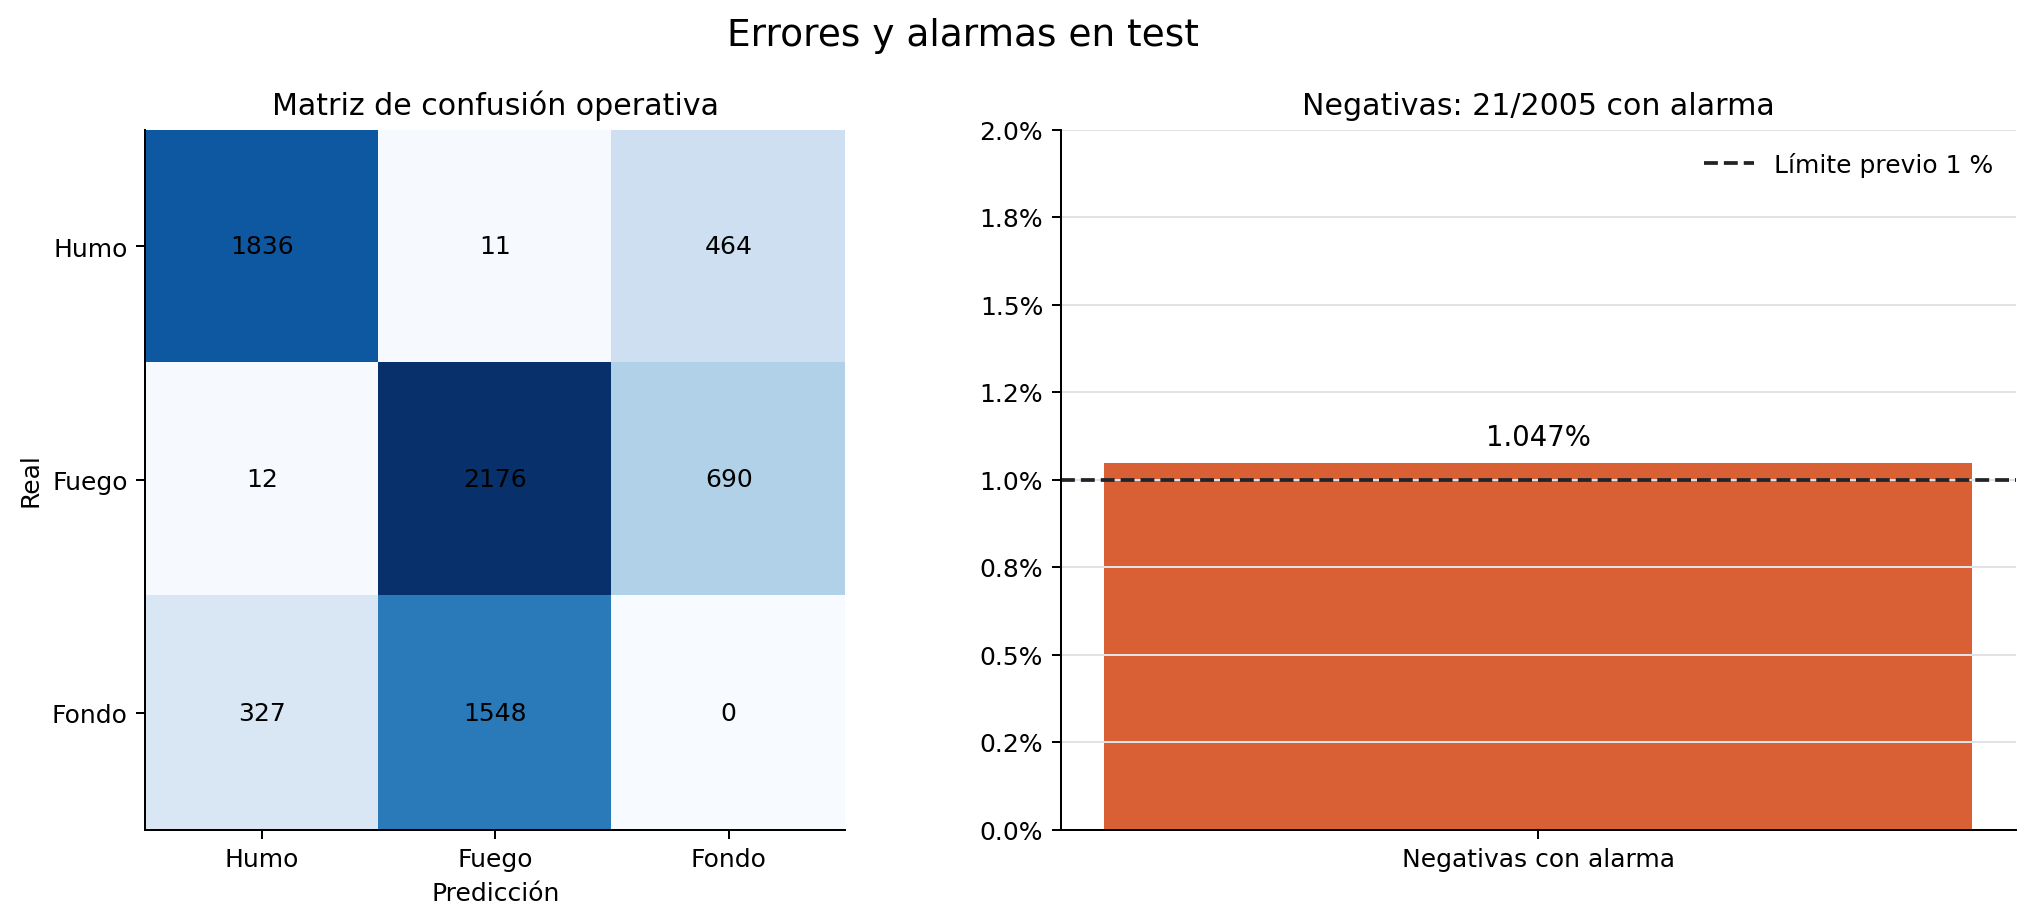

In [7]:
confusion = pd.read_csv(RUN / 'test_confusion_matrix.csv', index_col=0)
alarms = pd.read_csv(RUN / 'test_negative_image_alarms.csv')
display(confusion.rename(index={'smoke':'Humo real','fire':'Fuego real','background':'Fondo real'},
                         columns={'smoke':'Pred. humo','fire':'Pred. fuego','background':'Pred. fondo'}))
display(alarms.style.format({'negative_image_false_alarm_rate':'{:.3%}'}))
display(Image(filename=str(RUN / 'figures/04_errors_and_negative_alarms.png'), width=1000))

Hay alarma en 21 de las 2.005 imágenes sin humo ni fuego (1,05 %). Para
cumplir el 1 % el máximo era 20, así que se supera por una imagen. Se deja
así: subir un umbral después de ver el test sería ajustar el modelo con el
conjunto de evaluación final.

### 5. Ejemplos

Selección hecha a propósito: alarmas en imágenes sin humo ni fuego, fallos de
detección, cajas falsas en imágenes con incendio, confusiones entre clases y
aciertos. No indica con qué frecuencia ocurre cada caso.

,order,selection_reason,filename,gt_boxes,tp,fp,fn,max_confidence
0,1,alarma_negativa,WEB10230.jpg,0,0,1,0,0.729732
1,2,alarma_negativa,WEB10398.jpg,0,0,1,0,0.710755
2,3,alarma_negativa,WEB10418.jpg,0,0,1,0,0.701577
3,4,confusion_clase,WEB11160.jpg,10,1,13,9,0.902786
4,5,confusion_clase,WEB10504.jpg,3,1,4,2,0.907511
5,6,falso_negativo,WEB10524.jpg,23,9,8,14,0.763245
6,7,falso_negativo,WEB10605.jpg,10,1,3,9,0.764175
7,8,falso_negativo,WEB10464.jpg,10,2,0,8,0.670419
8,9,fp_en_positiva,WEB10887.jpg,13,7,13,6,0.821396
9,10,fp_en_positiva,WEB10888.jpg,7,4,13,3,0.696692


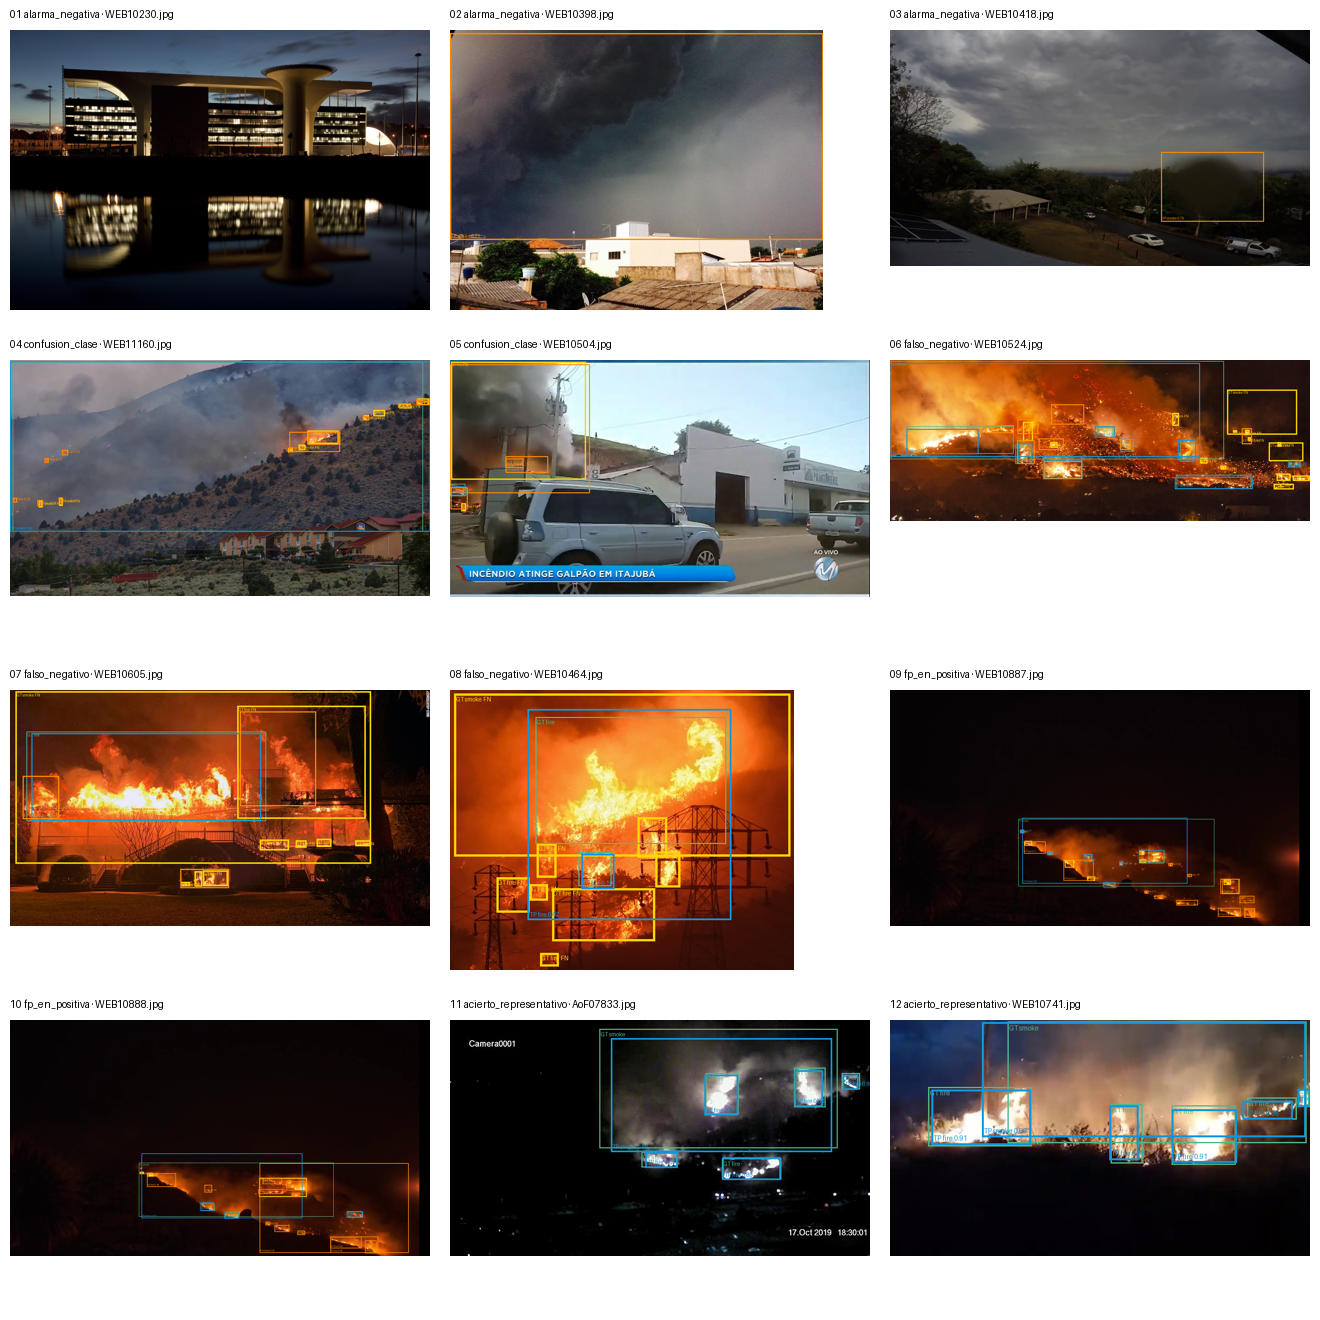

In [8]:
examples = pd.read_csv(RUN / 'representative_examples.csv')
display(examples[['order','selection_reason','filename','gt_boxes','tp','fp','fn','max_confidence']])
display(Image(filename=str(RUN / 'figures/05_representative_examples.png'), width=1100))

## Conclusiones

1. El modelo generaliza bien: el mAP50-95 pasa de 46,68 % en validación a
   46,38 % en test, y el F1 micro de 73,52 % a 72,29 %.
2. El humo es más preciso (84,41 %). El fuego tiene más cajas falsas: 58,26 %
   de precisión con 75,61 % de recall.
3. El límite de alarmas se supera ligeramente (1,05 % frente a 1 %); se informa
   tal cual, sin corregirlo con test.
4. Con esto termina la evaluación. Cualquier análisis posterior
   (interpretabilidad, despliegue) usa validación u otros datos, no test.